Step 1: Import necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

Step 2: Load the dataset

In [2]:
file_path = "D:\\Machine Learning Dataset\\WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Step 3: Basic Data Exploration

In [3]:
print("Dataset Info:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())
print("\nDataset description:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-n

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Step 4: Handle missing values and data type issues

In [4]:
# Check for empty strings or spaces in TotalCharges
print("Unique values in TotalCharges before cleaning:")
print(df['TotalCharges'].unique()[:10])

# Convert TotalCharges to numeric, handling empty strings
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check for missing values after conversion
print("\nMissing values after conversion:")
print(df.isnull().sum())

# Fill missing TotalCharges with 0 (likely new customers)
df['TotalCharges'].fillna(0, inplace=True)

print("\nMissing values after handling:")
print(df.isnull().sum())

Unique values in TotalCharges before cleaning:
['29.85' '1889.5' '108.15' '1840.75' '151.65' '820.5' '1949.4' '301.9'
 '3046.05' '3487.95']

Missing values after conversion:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Missing values after handling:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV 

Step 5: Visualize missing values

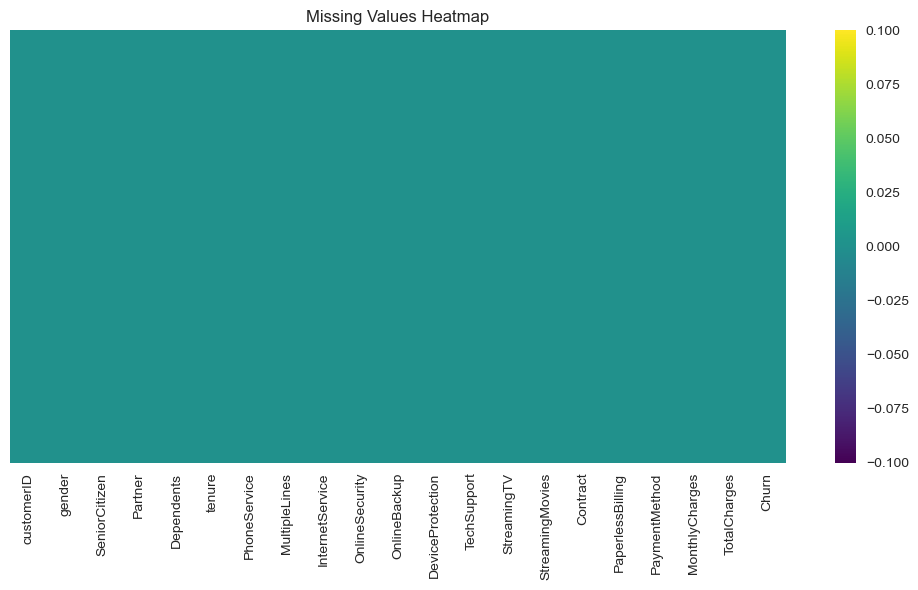

In [5]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.tight_layout()
plt.show()

Step 6: Exploratory Data Analysis - Target Variable Distribution

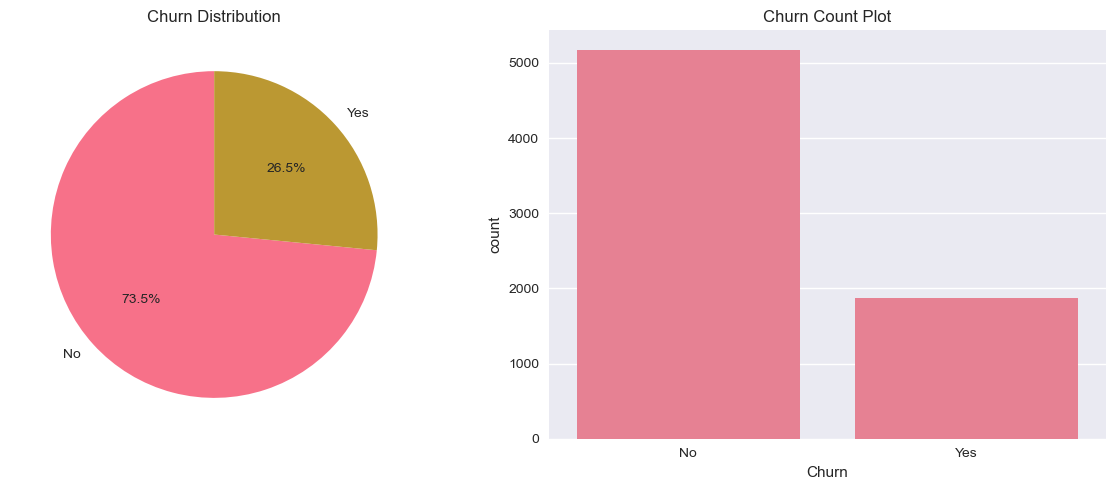

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [6]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
churn_counts = df['Churn'].value_counts()
plt.pie(churn_counts.values, labels=churn_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Churn Distribution')

plt.subplot(1, 2, 2)
sns.countplot(data=df, x='Churn')
plt.title('Churn Count Plot')
plt.tight_layout()
plt.show()

print("Churn distribution:")
print(churn_counts)

Step 7: Analyze numerical features distribution

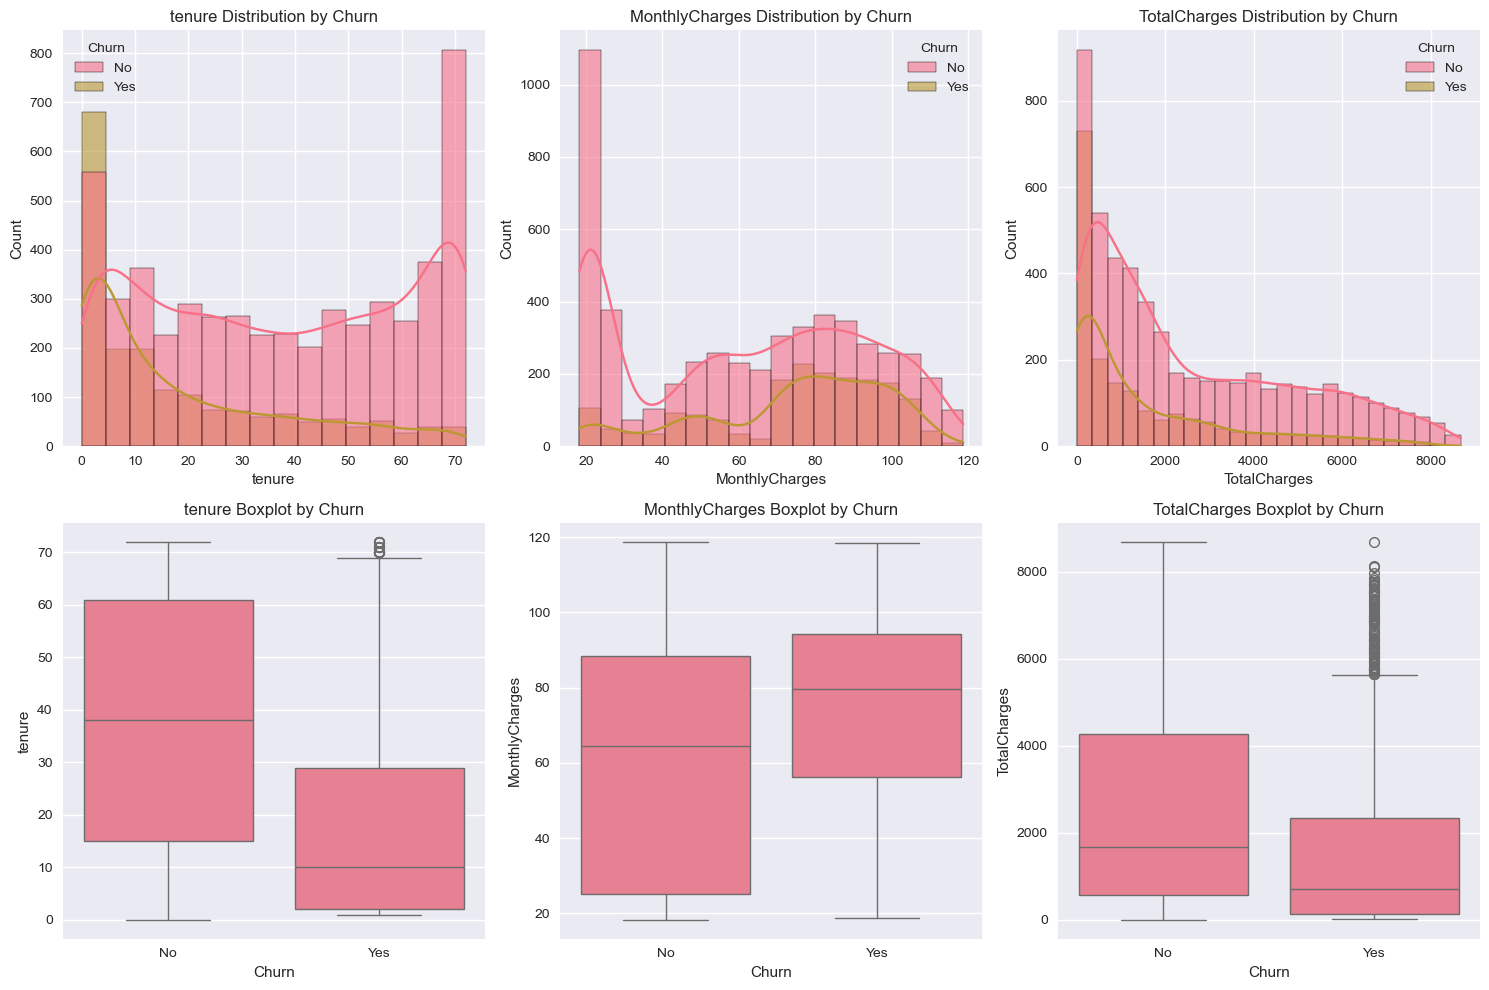

In [7]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(data=df, x=col, hue='Churn', kde=True, alpha=0.6)
    plt.title(f'{col} Distribution by Churn')
    
    plt.subplot(2, 3, i+3)
    sns.boxplot(data=df, x='Churn', y=col)
    plt.title(f'{col} Boxplot by Churn')

plt.tight_layout()
plt.show()

Step 8: Analyze categorical features

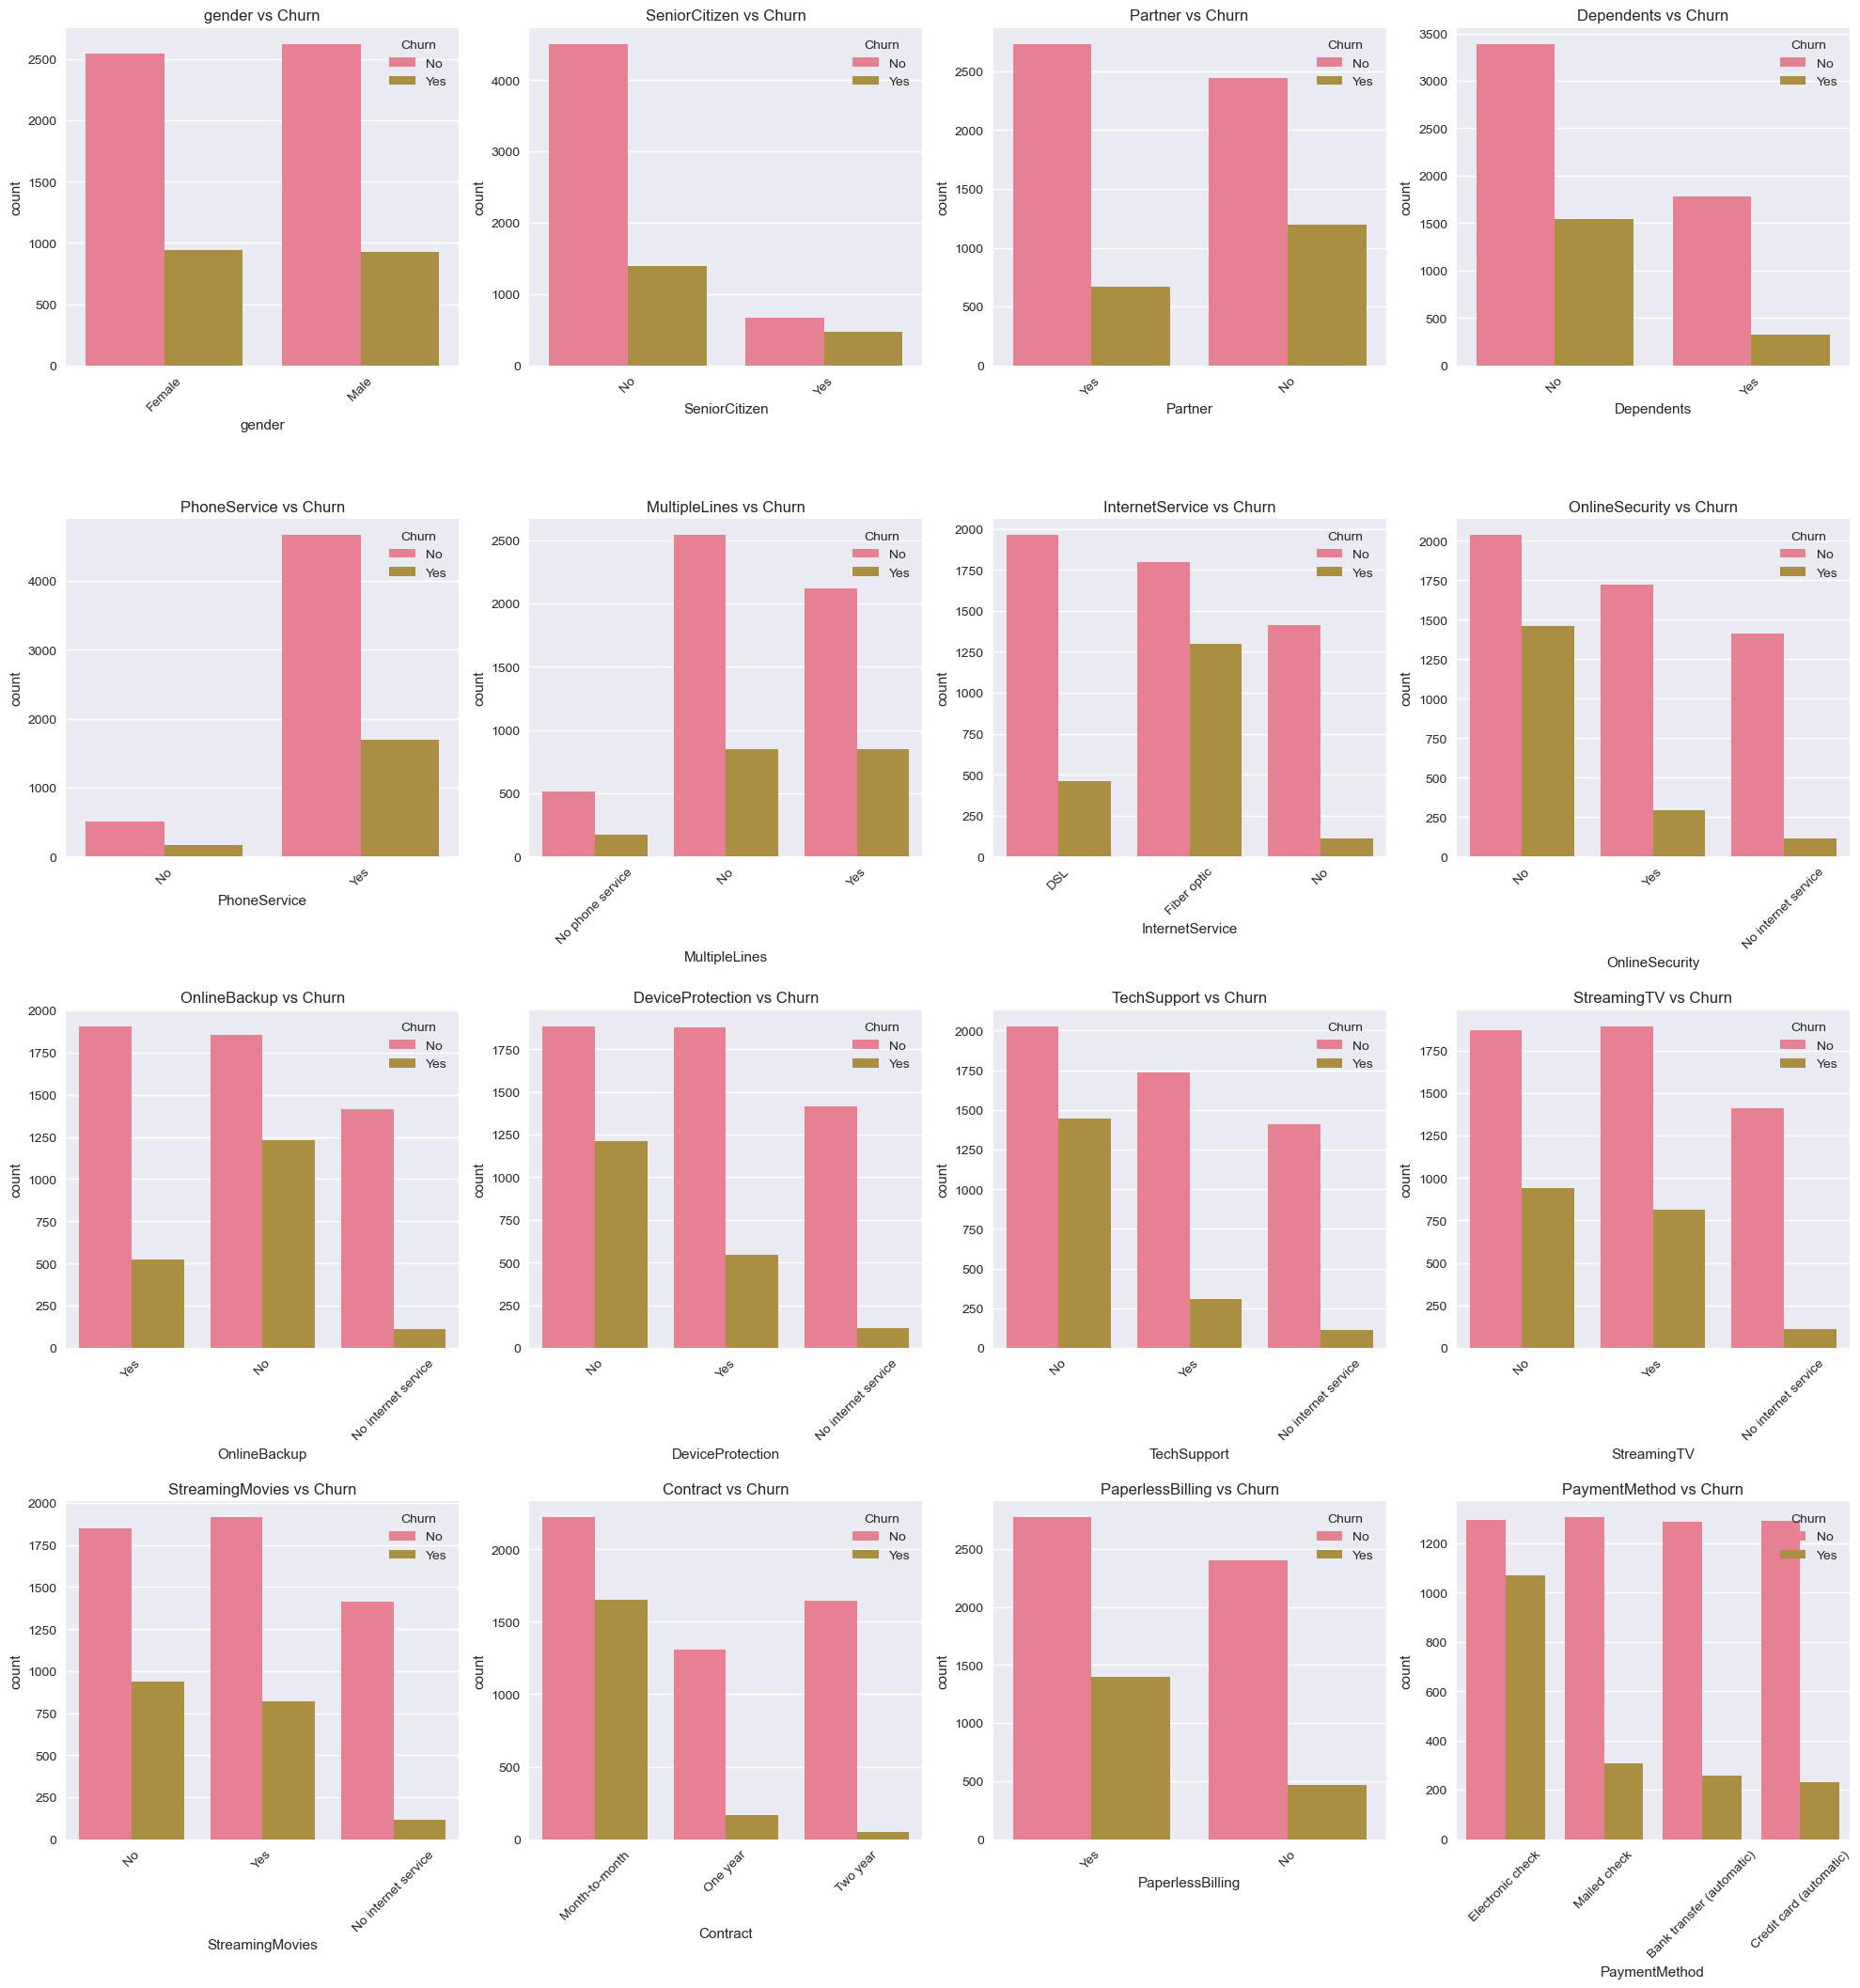

In [8]:
categorical_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 
                   'PhoneService', 'MultipleLines', 'InternetService', 
                   'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                   'TechSupport', 'StreamingTV', 'StreamingMovies', 
                   'Contract', 'PaperlessBilling', 'PaymentMethod']

# Convert SeniorCitizen to categorical for better visualization
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

plt.figure(figsize=(20, 25))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(5, 4, i)
    sns.countplot(data=df, x=col, hue='Churn')
    plt.title(f'{col} vs Churn')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Step 9: Correlation Heatmap

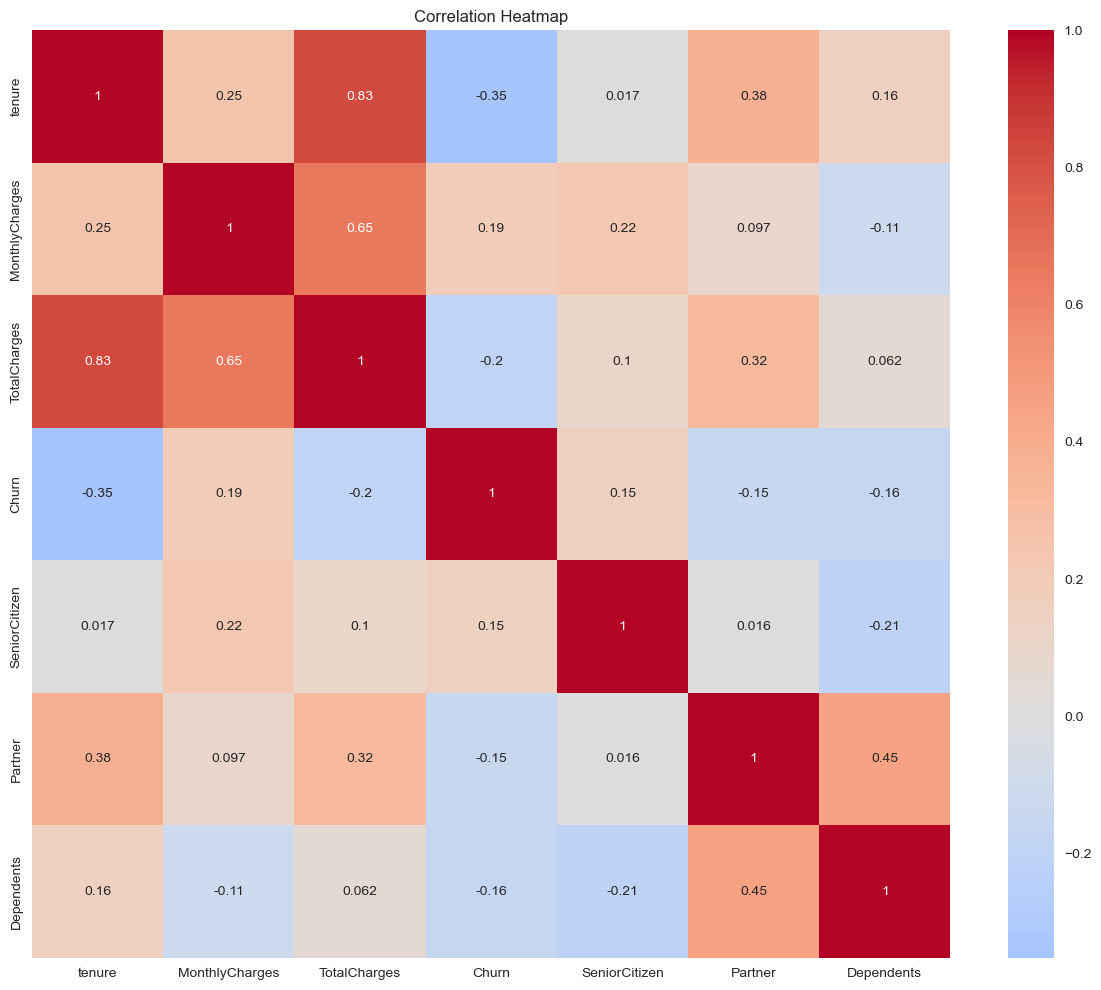

In [9]:
# Convert categorical variables to numerical for correlation analysis
df_corr = df.copy()
label_encoders = {}

for col in ['Churn', 'gender', 'Partner', 'Dependents', 'PhoneService', 
            'PaperlessBilling', 'SeniorCitizen']:
    le = LabelEncoder()
    df_corr[col] = le.fit_transform(df_corr[col])
    label_encoders[col] = le

plt.figure(figsize=(12, 10))
correlation_matrix = df_corr[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn'] + 
                            ['SeniorCitizen', 'Partner', 'Dependents']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

Step 10: Feature Engineering - Create new features

In [10]:
# 1. Tenure groups
df['TenureGroup'] = pd.cut(df['tenure'], 
                          bins=[0, 12, 24, 48, 72], 
                          labels=['0-1 Year', '1-2 Years', '2-4 Years', '4+ Years'])

# 2. Monthly charge groups
df['MonthlyChargeGroup'] = pd.cut(df['MonthlyCharges'], 
                                 bins=[0, 35, 70, 90, 120], 
                                 labels=['Low', 'Medium', 'High', 'Very High'])

# 3. Total services subscribed
services = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 
           'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

df['TotalServices'] = 0
for service in services:
    df['TotalServices'] += (df[service] == 'Yes').astype(int)

# 4. Internet service type flag
df['HasInternetService'] = (df['InternetService'] != 'No').astype(int)

# 5. Customer value (MonthlyCharges * tenure)
df['CustomerValue'] = df['MonthlyCharges'] * df['tenure']

print("New features created:")
print(df[['TenureGroup', 'MonthlyChargeGroup', 'TotalServices', 'HasInternetService', 'CustomerValue']].head())

New features created:
  TenureGroup MonthlyChargeGroup  TotalServices  HasInternetService  \
0    0-1 Year                Low              1                   1   
1   2-4 Years             Medium              3                   1   
2    0-1 Year             Medium              3                   1   
3   2-4 Years             Medium              3                   1   
4    0-1 Year               High              1                   1   

   CustomerValue  
0          29.85  
1        1936.30  
2         107.70  
3        1903.50  
4         141.40  


Step 11: Visualize newly created features

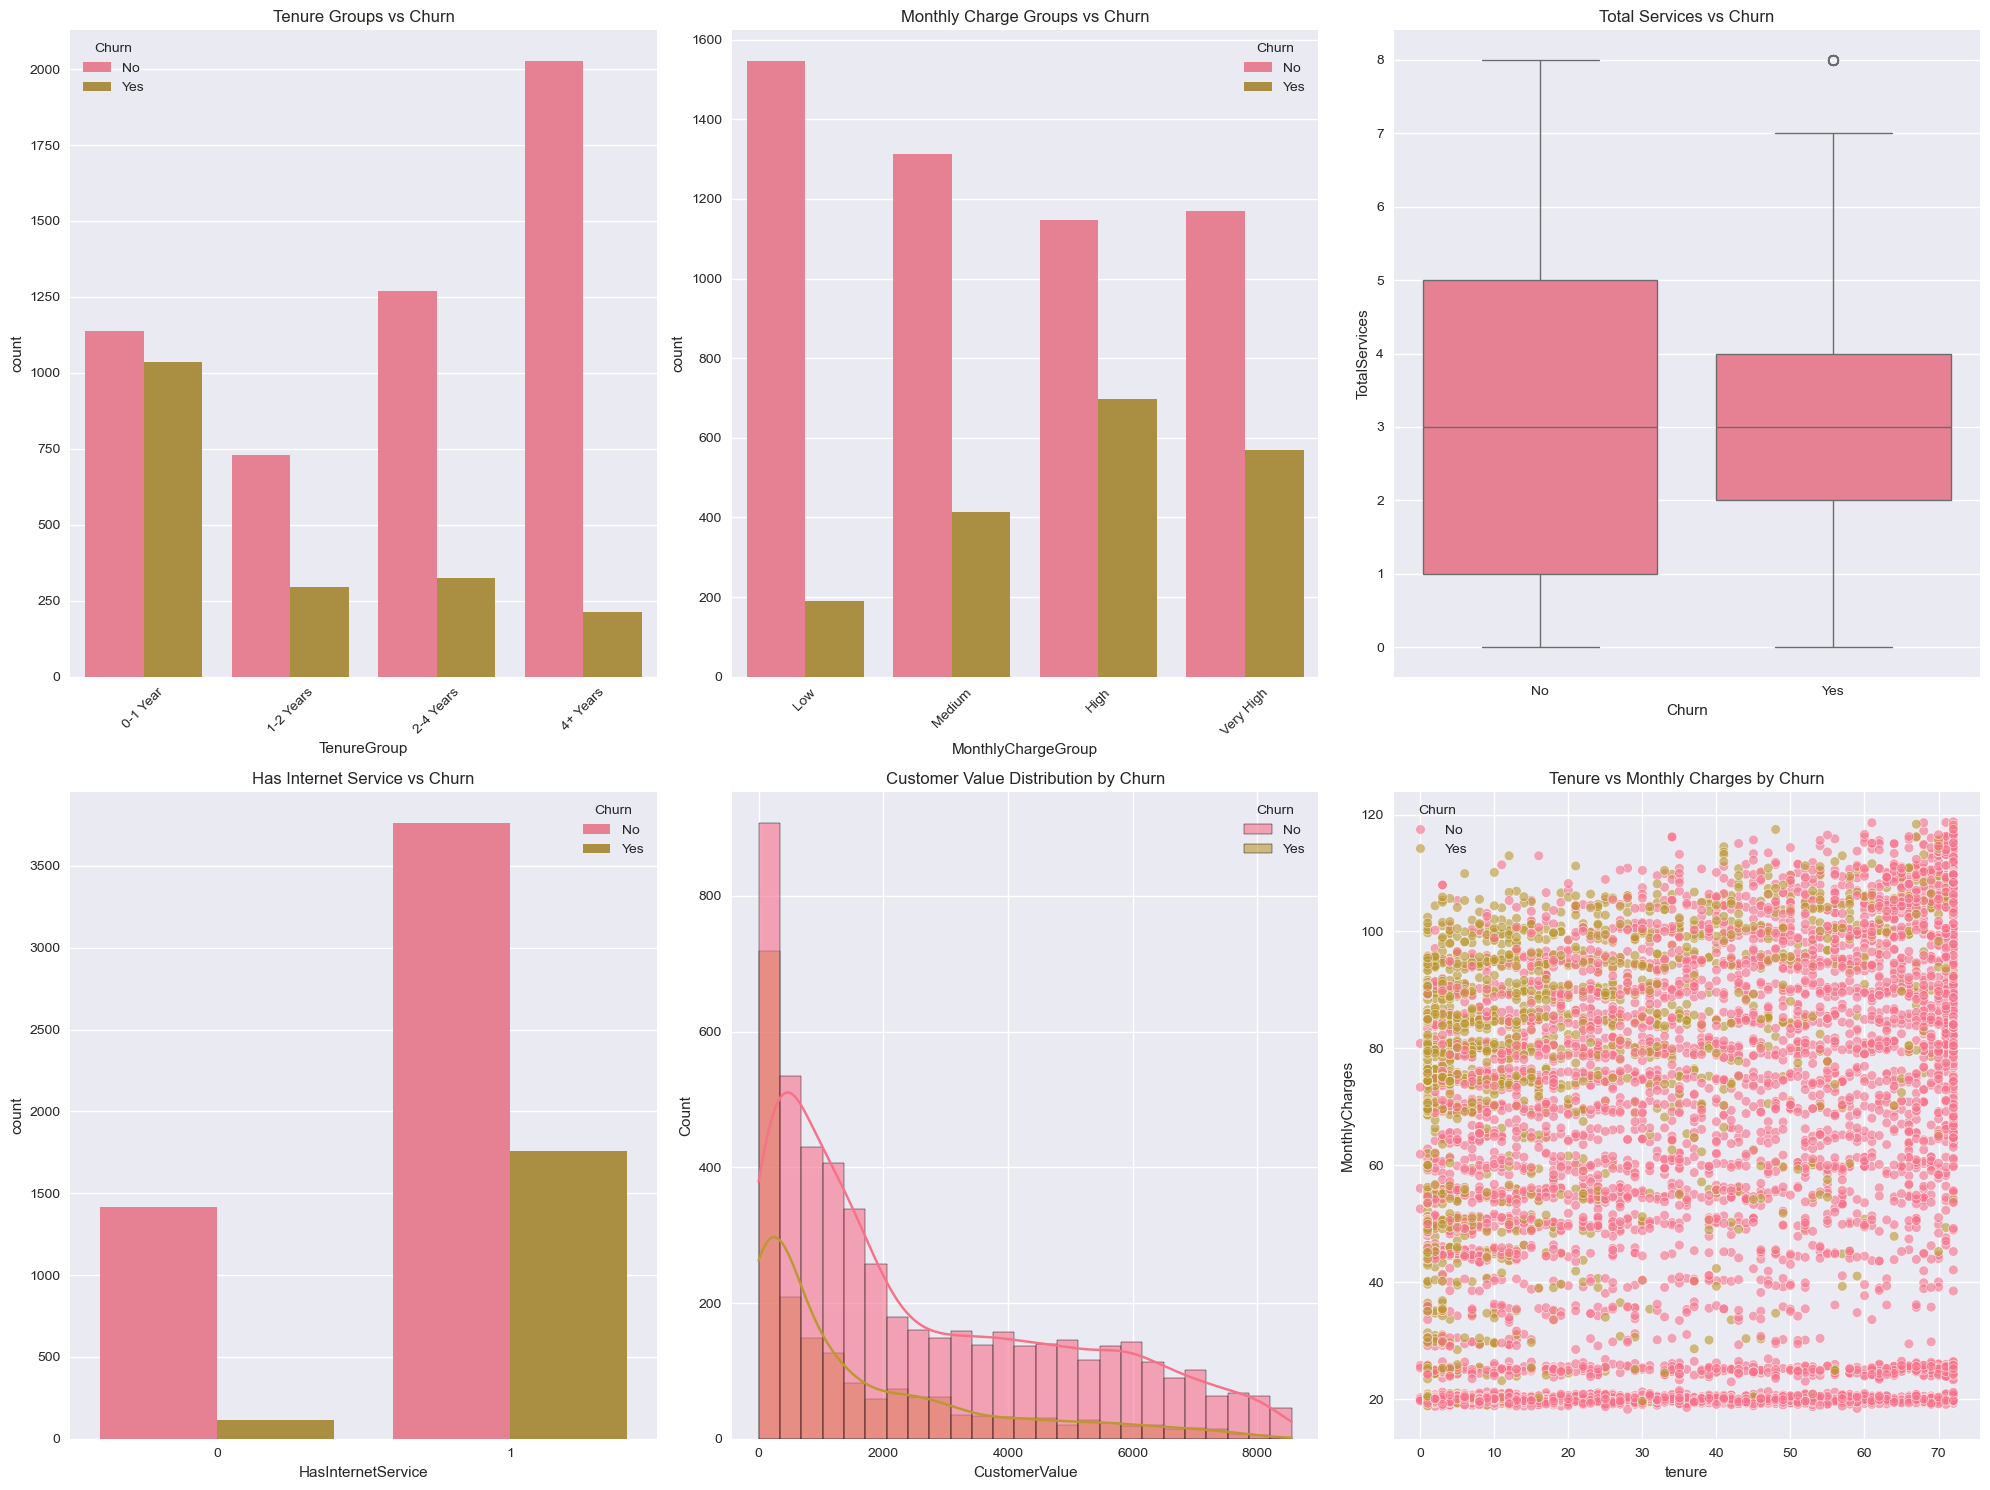

In [11]:
plt.figure(figsize=(20, 15))

plt.subplot(2, 3, 1)
sns.countplot(data=df, x='TenureGroup', hue='Churn')
plt.title('Tenure Groups vs Churn')
plt.xticks(rotation=45)

plt.subplot(2, 3, 2)
sns.countplot(data=df, x='MonthlyChargeGroup', hue='Churn')
plt.title('Monthly Charge Groups vs Churn')
plt.xticks(rotation=45)

plt.subplot(2, 3, 3)
sns.boxplot(data=df, x='Churn', y='TotalServices')
plt.title('Total Services vs Churn')

plt.subplot(2, 3, 4)
sns.countplot(data=df, x='HasInternetService', hue='Churn')
plt.title('Has Internet Service vs Churn')

plt.subplot(2, 3, 5)
sns.histplot(data=df, x='CustomerValue', hue='Churn', kde=True, alpha=0.6)
plt.title('Customer Value Distribution by Churn')

plt.subplot(2, 3, 6)
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges', hue='Churn', alpha=0.6)
plt.title('Tenure vs Monthly Charges by Churn')

plt.tight_layout()
plt.show()

Step 12: Handle categorical variables - Encoding

In [12]:
# Create a copy for encoding
df_encoded = df.copy()

# Label encoding for binary variables
binary_cols = ['gender', 'Partner', 'Dependents', 'PaperlessBilling', 
               'Churn', 'HasInternetService']
label_encoders = {}

for col in binary_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

# One-hot encoding for multi-category variables
multi_cat_cols = ['InternetService', 'Contract', 'PaymentMethod', 
                  'TenureGroup', 'MonthlyChargeGroup']

df_encoded = pd.get_dummies(df_encoded, columns=multi_cat_cols, drop_first=True)

# Handle other categorical columns
other_cat_cols = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 
                  'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in other_cat_cols:
    # Simplify to binary (Yes/No) ignoring 'No internet service'
    df_encoded[col] = df_encoded[col].apply(lambda x: 1 if x == 'Yes' else 0)

print("Encoded dataset shape:", df_encoded.shape)
print("\nEncoded columns:")
print(df_encoded.columns.tolist())

Encoded dataset shape: (7043, 34)

Encoded columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'TotalServices', 'HasInternetService', 'CustomerValue', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'TenureGroup_1-2 Years', 'TenureGroup_2-4 Years', 'TenureGroup_4+ Years', 'MonthlyChargeGroup_Medium', 'MonthlyChargeGroup_High', 'MonthlyChargeGroup_Very High']


Step 13: Feature Scaling

In [13]:
# Select numerical features to scale
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'TotalServices', 'CustomerValue']

# Initialize scaler
scaler = StandardScaler()

# Scale numerical features
df_encoded[numerical_features] = scaler.fit_transform(df_encoded[numerical_features])

print("Scaled numerical features statistics:")
print(df_encoded[numerical_features].describe())

Scaled numerical features statistics:
             tenure  MonthlyCharges  TotalCharges  TotalServices  \
count  7.043000e+03    7.043000e+03  7.043000e+03   7.043000e+03   
mean  -2.421273e-17   -6.406285e-17 -3.783239e-17  -5.044319e-17   
std    1.000071e+00    1.000071e+00  1.000071e+00   1.000071e+00   
min   -1.318165e+00   -1.545860e+00 -1.005780e+00  -1.630990e+00   
25%   -9.516817e-01   -9.725399e-01 -8.299464e-01  -1.145997e+00   
50%   -1.372744e-01    1.857327e-01 -3.905282e-01  -1.760106e-01   
75%    9.214551e-01    8.338335e-01  6.648034e-01   7.939757e-01   
max    1.613701e+00    1.794352e+00  2.825806e+00   2.248955e+00   

       CustomerValue  
count   7.043000e+03  
mean    3.026591e-17  
std     1.000071e+00  
min    -1.006629e+00  
25%    -8.326448e-01  
50%    -3.912362e-01  
75%     6.652563e-01  
max     2.768924e+00  


Step 14: Final dataset preparation - FIXED VERSION

Final feature matrix shape: (7043, 32)
Target variable shape: (7043,)


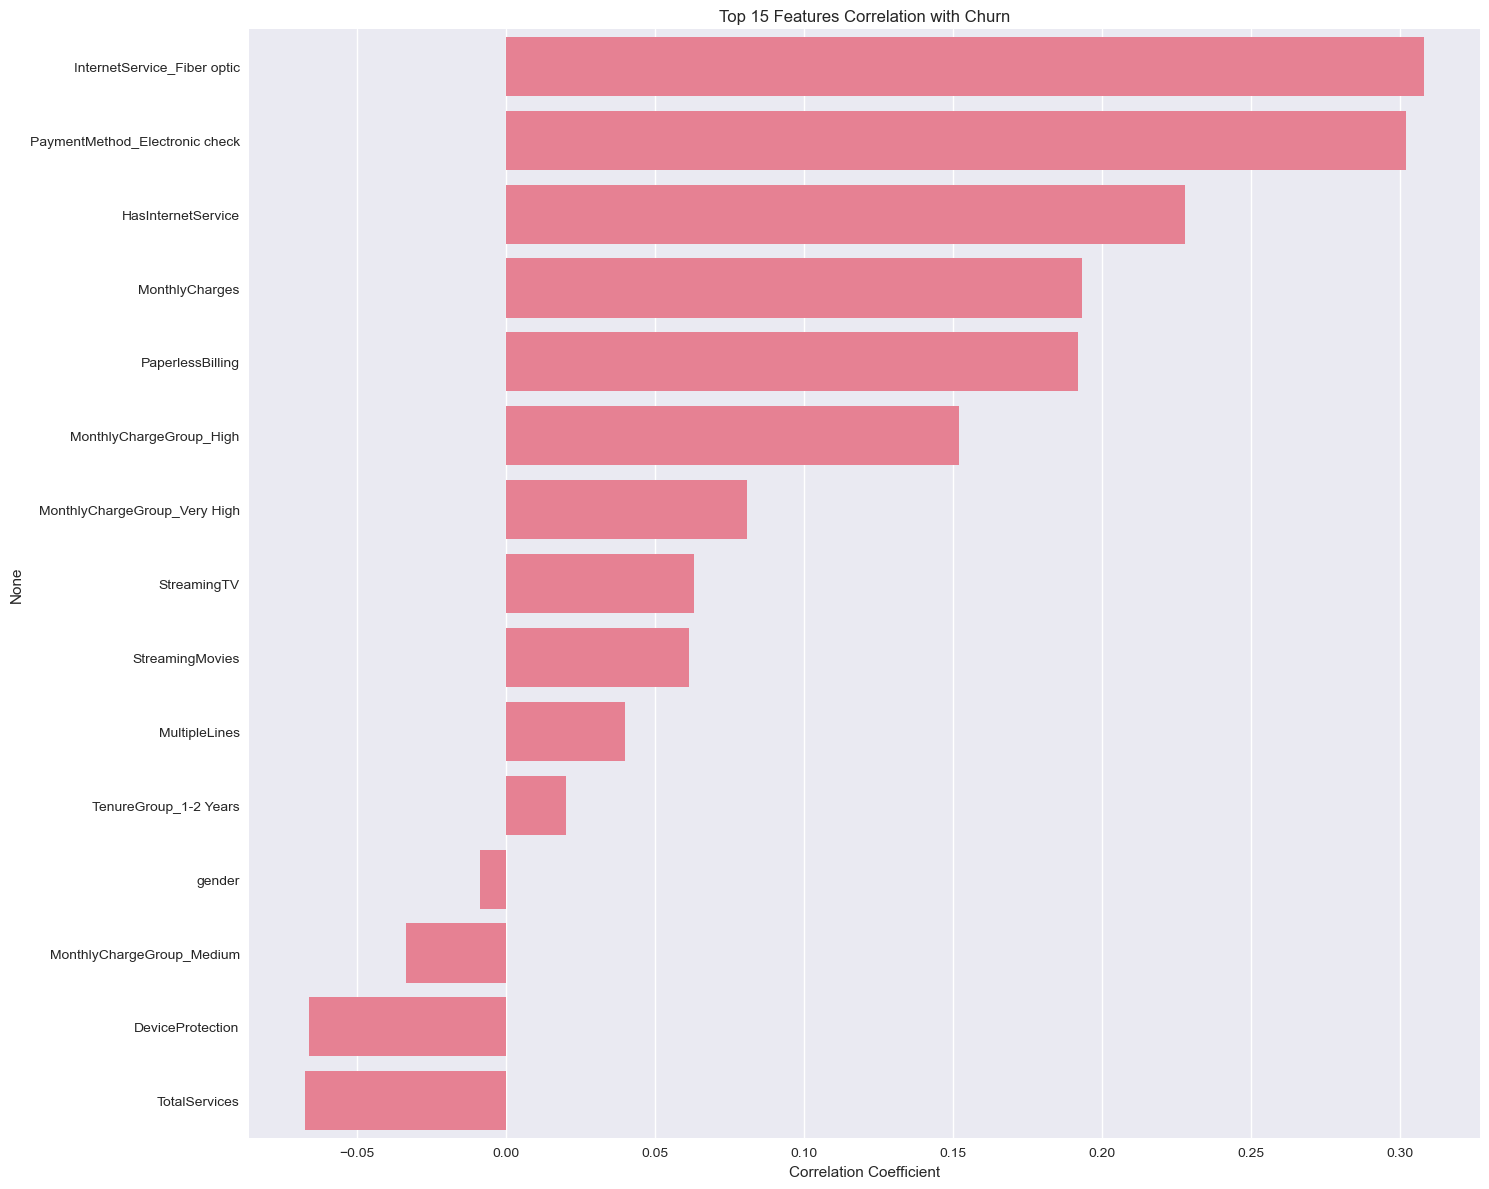

Top 15 features correlated with Churn:
InternetService_Fiber optic       0.308020
PaymentMethod_Electronic check    0.301919
HasInternetService                0.227890
MonthlyCharges                    0.193356
PaperlessBilling                  0.191825
MonthlyChargeGroup_High           0.151897
MonthlyChargeGroup_Very High      0.080929
StreamingTV                       0.063228
StreamingMovies                   0.061382
MultipleLines                     0.040102
TenureGroup_1-2 Years             0.020308
gender                           -0.008612
MonthlyChargeGroup_Medium        -0.033473
DeviceProtection                 -0.066160
TotalServices                    -0.067264
Name: Churn, dtype: float64


In [16]:
# Separate features and target
X = df_encoded.drop(['customerID', 'Churn'], axis=1)
y = df_encoded['Churn']

print("Final feature matrix shape:", X.shape)
print("Target variable shape:", y.shape)

# Display feature importance correlation
# First, create a temporary dataframe without customerID for correlation calculation
df_corr_temp = df_encoded.drop('customerID', axis=1)

# Convert all columns to numeric (in case there are any non-numeric columns left)
for col in df_corr_temp.columns:
    df_corr_temp[col] = pd.to_numeric(df_corr_temp[col], errors='coerce')

plt.figure(figsize=(15, 12))
correlation_with_target = df_corr_temp.corr()['Churn'].sort_values(ascending=False)

# Remove Churn itself from the list and get top 15 features
correlation_with_target = correlation_with_target[correlation_with_target.index != 'Churn'].head(15)

sns.barplot(x=correlation_with_target.values, y=correlation_with_target.index)
plt.title('Top 15 Features Correlation with Churn')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

print("Top 15 features correlated with Churn:")
print(correlation_with_target)

Step 15: Train-test split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=42, 
                                                    stratify=y)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("\nChurn distribution in training set:")
print(y_train.value_counts(normalize=True))
print("\nChurn distribution in testing set:")
print(y_test.value_counts(normalize=True))

Training set shape: (5634, 32)
Testing set shape: (1409, 32)

Churn distribution in training set:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Churn distribution in testing set:
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


Step 16: Summary of feature engineering steps

In [18]:
print("=== FEATURE ENGINEERING SUMMARY ===")
print(f"Original dataset shape: {pd.read_csv(file_path).shape}")
print(f"Final dataset shape: {X.shape}")
print(f"Number of features created: {X.shape[1]}")
print(f"Missing values handled: Yes")
print(f"Categorical variables encoded: Yes")
print(f"Numerical features scaled: Yes")
print(f"New features created: 5")

print("\n=== KEY INSIGHTS ===")
print("1. Dataset is imbalanced (73.5% No Churn vs 26.5% Churn)")
print("2. Tenure and TotalCharges are negatively correlated with churn")
print("3. MonthlyCharges is positively correlated with churn")
print("4. Contract type and internet service are strong predictors")
print("5. Customers with higher tenure are less likely to churn")

=== FEATURE ENGINEERING SUMMARY ===
Original dataset shape: (7043, 21)
Final dataset shape: (7043, 32)
Number of features created: 32
Missing values handled: Yes
Categorical variables encoded: Yes
Numerical features scaled: Yes
New features created: 5

=== KEY INSIGHTS ===
1. Dataset is imbalanced (73.5% No Churn vs 26.5% Churn)
2. Tenure and TotalCharges are negatively correlated with churn
3. MonthlyCharges is positively correlated with churn
4. Contract type and internet service are strong predictors
5. Customers with higher tenure are less likely to churn
